# EDA — Letterboxd Reviews Dataset (`resenas_completo.jsonl`)

Exploratory data analysis of a scraped Letterboxd film-review dataset.

Each line in the source file is a JSON object with the following fields:

| field | meaning |
|---|---|
| `id` | unique review id |
| `pelicula_slug` | film slug (Letterboxd URL key) |
| `usuario` | reviewer username |
| `nombre_visible` | reviewer display name |
| `url` | review URL |
| `calificacion` | star rating, 0.5–5.0 |
| `fecha` | date the review was posted |
| `texto` | review text |
| `likes` | number of likes on the review |
| `spoiler` | spoiler flag (0/1) |
| `idioma` | detected language of the review |
| `es_relectura` | rewatch flag (0/1) |
| `recolectado_en` | timestamp when the row was scraped |
| `pelicula_titulo` | film title |
| `pelicula_anio` | film release year |

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Works both when run locally next to the file and inside the Docker
# container, where the file is mounted at /work/resenas_completo.jsonl.
DATA_PATH = os.environ.get(
    "DATA_PATH",
    "resenas_completo.jsonl" if os.path.exists("resenas_completo.jsonl") else "/work/resenas_completo.jsonl",
)
print("Loading:", DATA_PATH)

Loading: resenas_completo.jsonl


## 1. Load the data

In [2]:
%%time
# pandas.read_json(lines=True) chokes on this file even though every line is
# valid JSON on its own (its whole-file line-combining path is fragile at
# this size), so parse line by line instead — simpler and more robust.
records = []
with open(DATA_PATH, encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame.from_records(records)
del records

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["recolectado_en"] = pd.to_datetime(df["recolectado_en"], errors="coerce", utc=True)
print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head()

710,045 rows x 15 columns
CPU times: total: 8.11 s
Wall time: 8.83 s


,id,pelicula_slug,usuario,nombre_visible,url,calificacion,fecha,texto,likes,spoiler,idioma,es_relectura,recolectado_en,pelicula_titulo,pelicula_anio
0,viewing:76452081,108-stitches-2019,fansee,Fansee,https://letterboxd.com/fansee/film/108-stitche...,0.5,2019-10-07,I was torn between watching The Humanity Burea...,0,0,en,0,2026-09-18 02:02:59+00:00,108 Stitches,2019
1,viewing:77095670,108-stitches-2019,gerardacerezo,Gerarda,https://letterboxd.com/gerardacerezo/film/108-...,1.5,2019-10-14,"la intención es buena la ejecución, pésima.",0,0,es,0,2026-09-18 02:02:59+00:00,108 Stitches,2019
2,viewing:77468802,108-stitches-2019,binoculares,binoculares,https://letterboxd.com/binoculares/film/108-st...,1.0,2019-10-19,Vi esta película porque escuché una entrevista...,1,0,es,0,2026-09-18 02:02:59+00:00,108 Stitches,2019
3,viewing:170679204,108-stitches-2019,gorelliez,ellie,https://letterboxd.com/gorelliez/film/108-stit...,3.5,2019-10-23,"muy predecible, pero también muy bonita",0,0,es,0,2026-09-18 02:02:59+00:00,108 Stitches,2019
4,viewing:77842997,108-stitches-2019,honeyize,ellie,https://letterboxd.com/honeyize/film/108-stitc...,3.5,2019-10-23,"muy predecible, pero también muy bonita",1,0,es,0,2026-09-18 02:02:59+00:00,108 Stitches,2019


In [3]:
df.dtypes

id                              object
pelicula_slug                   object
usuario                         object
nombre_visible                  object
url                             object
calificacion                   float64
fecha                   datetime64[ns]
texto                           object
likes                            int64
spoiler                          int64
idioma                          object
es_relectura                     int64
recolectado_en     datetime64[ns, UTC]
pelicula_titulo                 object
pelicula_anio                    int64
dtype: object

In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,710045,710045,viewing:76452081,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pelicula_slug,710045,868,el,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
usuario,710045,340692,lencho_o_t_apes,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_visible,710045,283966,Alex,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,710045,710045,https://letterboxd.com/fansee/film/108-stitche...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calificacion,673224.0,NaN,NaN,NaN,3.380076,0.5,3.0,3.5,4.0,5.0,1.147977
fecha,693755,NaN,NaN,NaN,2024-10-23 18:25:20.971524608,1741-03-10 00:00:00,2024-03-10 00:00:00,2025-07-05 00:00:00,2026-03-30 00:00:00,2026-09-19 00:00:00,NaN
texto,710045,666566,This review may contain spoilers. I can handle...,16527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,710045.0,NaN,NaN,NaN,1.214705,0.0,0.0,0.0,1.0,1704.0,7.427426
spoiler,710045.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Data quality: missing values & duplicates

In [5]:
missing = df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(df) * 100).round(2)
empty_text = (df["texto"].fillna("").str.strip() == "").sum()
print(f"Empty/blank review text: {empty_text:,} ({empty_text/len(df)*100:.2f}%)")
print(f"Duplicate review ids: {df['id'].duplicated().sum():,}")
print(f"Fully duplicate rows: {df.duplicated().sum():,}")

# `fecha` contains a handful of implausible placeholder dates (year 1, 2, 10,
# 777, ...) rather than genuine watch dates — likely Letterboxd's default for
# diary entries logged without an explicit date. Flag them instead of letting
# them silently distort the min date / time series below.
implausible_dates = df["fecha"].dt.year < 1900
print(f"Filas con fechas irreales (<1900): {implausible_dates.sum():,} ({implausible_dates.mean()*100:.3f}%)")

missing

Empty/blank review text: 0 (0.00%)
Duplicate review ids: 0
Fully duplicate rows: 0
Filas con fechas irreales (<1900): 3 (0.000%)


,n_missing,pct_missing
id,0,0.00
pelicula_slug,0,0.00
usuario,0,0.00
nombre_visible,0,0.00
url,0,0.00
calificacion,36821,5.19
fecha,16290,2.29
texto,0,0.00
likes,0,0.00
spoiler,0,0.00


## 3. Dataset footprint

In [ ]:
plausible_dates = df.loc[~implausible_dates, "fecha"]

print(f"Reviews: {len(df):,}")
print(f"Peliculas: {df['pelicula_slug'].nunique():,}")
print(f"usuarios: {df['usuario'].nunique():,}")
print(f"Date range (excluding {implausible_dates.sum()} implausible placeholder dates): "
      f"{plausible_dates.min().date()} -> {plausible_dates.max().date()}")
print(f"Film release years: {int(df['pelicula_anio'].min())} -> {int(df['pelicula_anio'].max())}")

Reviews: 710,045
Unique films: 868
Unique reviewers: 340,692
Date range (excluding 3 implausible placeholder dates): 1911-11-11 -> 2026-09-19
Film release years: 1896 -> 2026


## 4. Ratings (`calificacion`)

count    673224.000000
mean          3.380076
std           1.147977
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: calificacion, dtype: float64

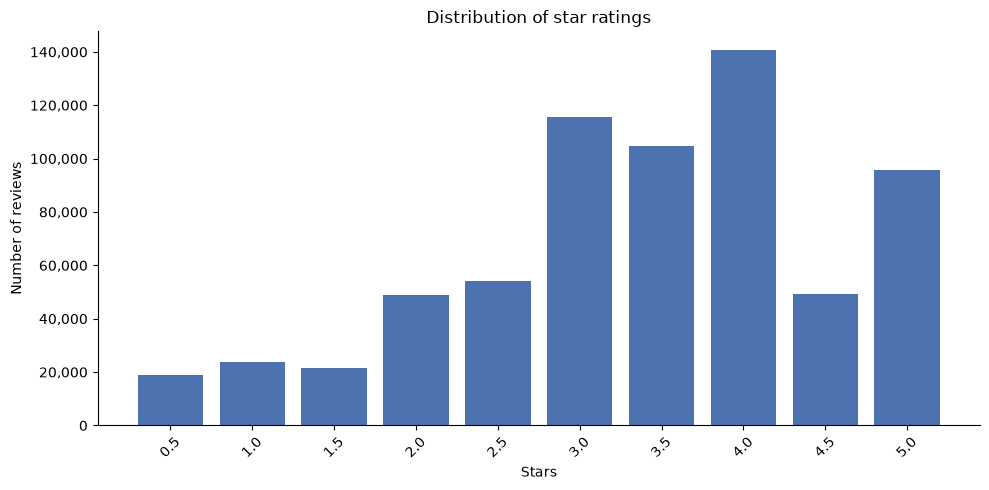

In [6]:
display(df["calificacion"].describe())

fig, ax = plt.subplots()
counts = df["calificacion"].value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, width=0.8, color="#4C72B0")
ax.set_title("Distribution of star ratings")
ax.set_xlabel("Stars")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Letterboxd's minimum rating is 0.5 stars, so `calificacion == 0` never
# occurs in practice; unrated reviews are stored as NaN instead (see the
# missing-values table above).
no_rating = df["calificacion"].isna().sum()
print(f"Reviews with no rating (NaN, text-only review): {no_rating:,} ({no_rating/len(df)*100:.2f}%)")

rated = df["calificacion"].dropna()
print(f"Mean rating: {rated.mean():.2f}")
print(f"Median rating: {rated.median():.2f}")

Reviews with no rating (NaN, text-only review): 36,821 (5.19%)
Mean rating: 3.38
Median rating: 3.50


## 5. Reviews over time

In [14]:
# Cantidad de reseñas por año (tabla completa)
by_year = df.loc[~implausible_dates].dropna(subset=['fecha']).groupby(df['fecha'].dt.year).size()
reseñas_por_anio = by_year.rename("n_reseñas").to_frame()
reseñas_por_anio["pct"] = (reseñas_por_anio["n_reseñas"] / reseñas_por_anio["n_reseñas"].sum() * 100).round(2)
print(f"Total de años con reseñas: {len(reseñas_por_anio)}")
reseñas_por_anio


Total de años con reseñas: 89


,n_reseñas,pct
fecha,,
1911.0,4,0.00
1934.0,3,0.00
1936.0,2,0.00
1939.0,1,0.00
1940.0,1,0.00
...,...,...
2022.0,32595,4.70
2023.0,60292,8.69
2024.0,104840,15.11


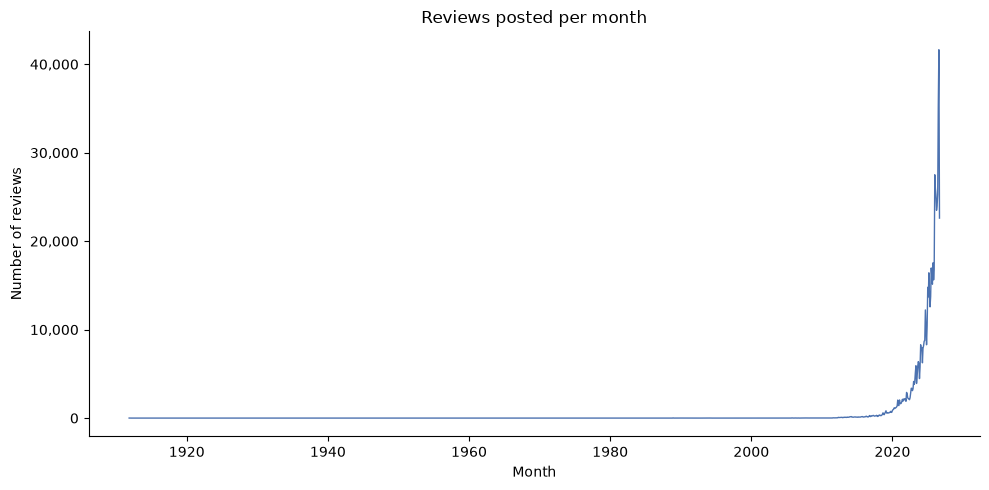

In [8]:
by_month = df.loc[~implausible_dates].dropna(subset=["fecha"]).set_index("fecha").resample("MS").size()

fig, ax = plt.subplots()
ax.plot(by_month.index, by_month.values, color="#4C72B0", linewidth=1)
ax.set_title("Reviews posted per month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

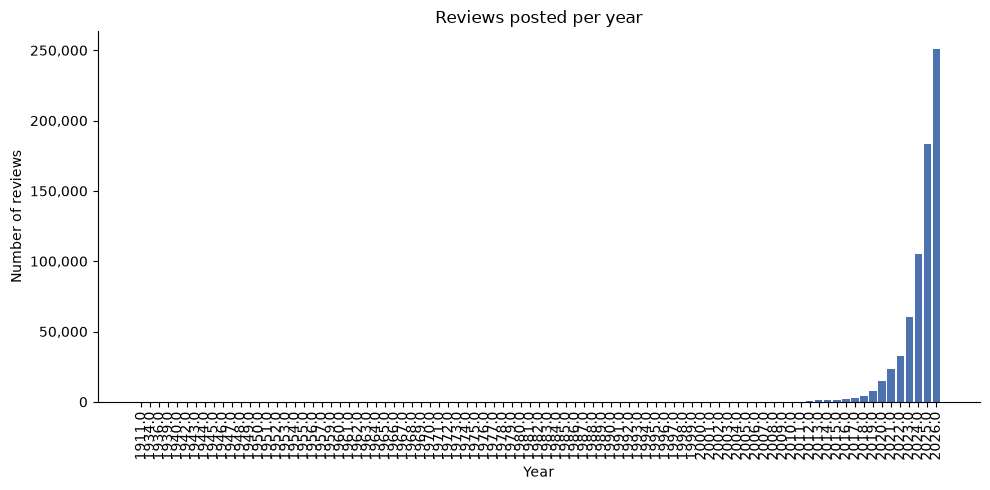

In [ ]:
by_year = df.loc[~implausible_dates].dropna(subset=["fecha"]).groupby(df["fecha"].dt.year).size()

fig, ax = plt.subplots()
ax.bar(by_year.index.astype(str), by_year.values, color="#4C72B0")
ax.set_title("Reviews posted per year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Cantidad de reseñas por año (tabla completa)
reseñas_por_anio = by_year.rename("n_reseñas").to_frame()
reseñas_por_anio["pct"] = (reseñas_por_anio["n_reseñas"] / reseñas_por_anio["n_reseñas"].sum() * 100).round(2)
print(f"Total de años con reseñas: {len(reseñas_por_anio)}")
reseñas_por_anio

## 6. Most-reviewed films

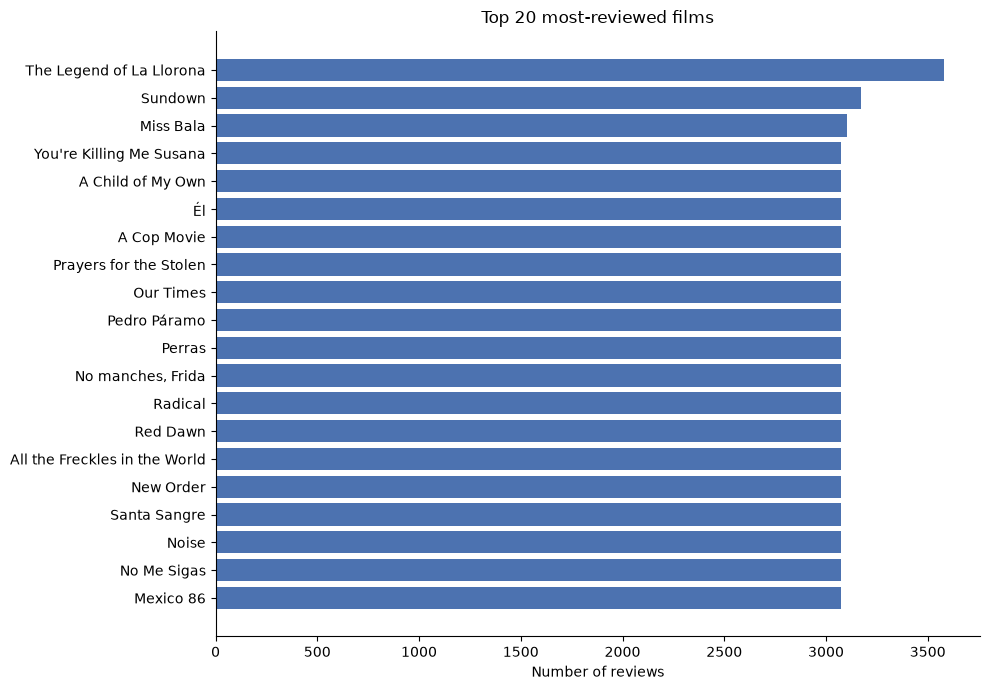

In [10]:
top_films = df["pelicula_titulo"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_films.index[::-1], top_films.values[::-1], color="#4C72B0")
ax.set_title("Top 20 most-reviewed films")
ax.set_xlabel("Number of reviews")
plt.tight_layout()
plt.show()

## 7. Most active reviewers

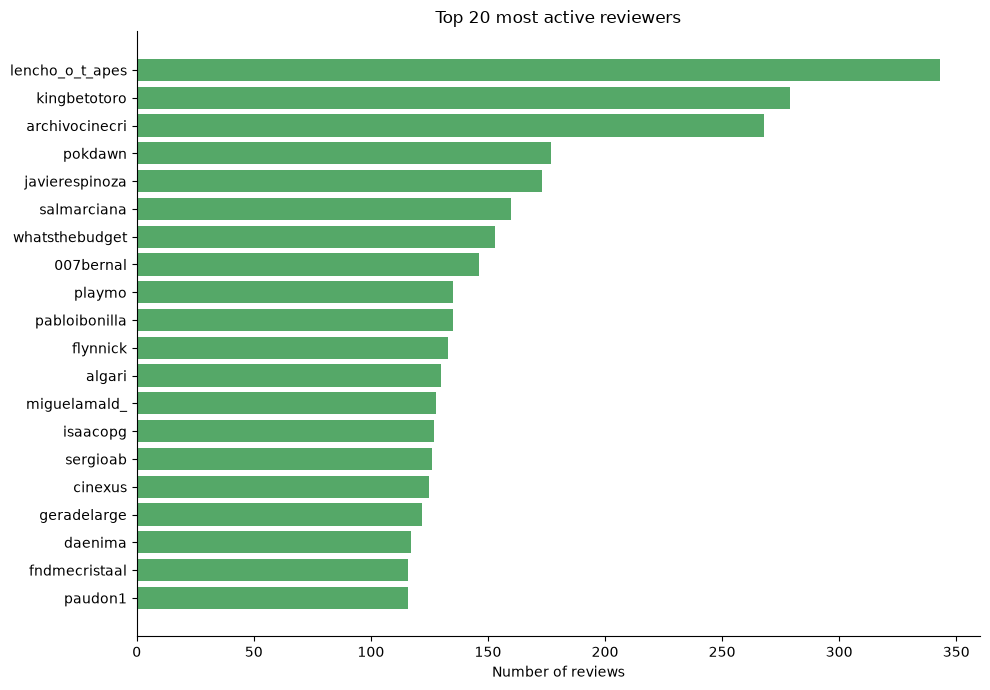

count    340692.000000
mean          2.084126
std           3.618029
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         343.000000
Name: count, dtype: float64


In [11]:
top_users = df["usuario"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_users.index[::-1], top_users.values[::-1], color="#55A868")
ax.set_title("Top 20 most active reviewers")
ax.set_xlabel("Number of reviews")
plt.tight_layout()
plt.show()

reviews_per_user = df["usuario"].value_counts()
print(reviews_per_user.describe())

## 8. Language distribution (`idioma`)

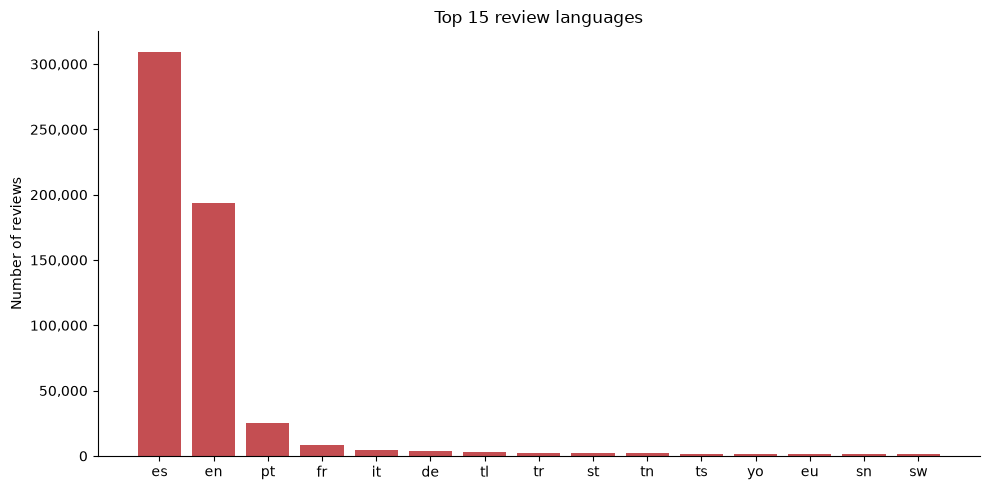

idioma
es    43.60
en    27.29
pt     3.51
fr     1.13
it     0.60
de     0.58
tl     0.44
tr     0.34
st     0.29
tn     0.28
ts     0.25
yo     0.25
eu     0.23
sn     0.18
sw     0.17
Name: count, dtype: float64

In [12]:
lang_counts = df["idioma"].value_counts().head(15)

fig, ax = plt.subplots()
ax.bar(lang_counts.index, lang_counts.values, color="#C44E52")
ax.set_title("Top 15 review languages")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

(lang_counts / len(df) * 100).round(2)

## 9. Review length

,n_chars,n_words
count,710045.000000,710045.000000
mean,150.149451,26.595495
std,157.451103,27.229129
min,1.000000,1.000000
25%,36.000000,7.000000
50%,78.000000,14.000000
75%,215.000000,38.000000
max,5850.000000,119.000000


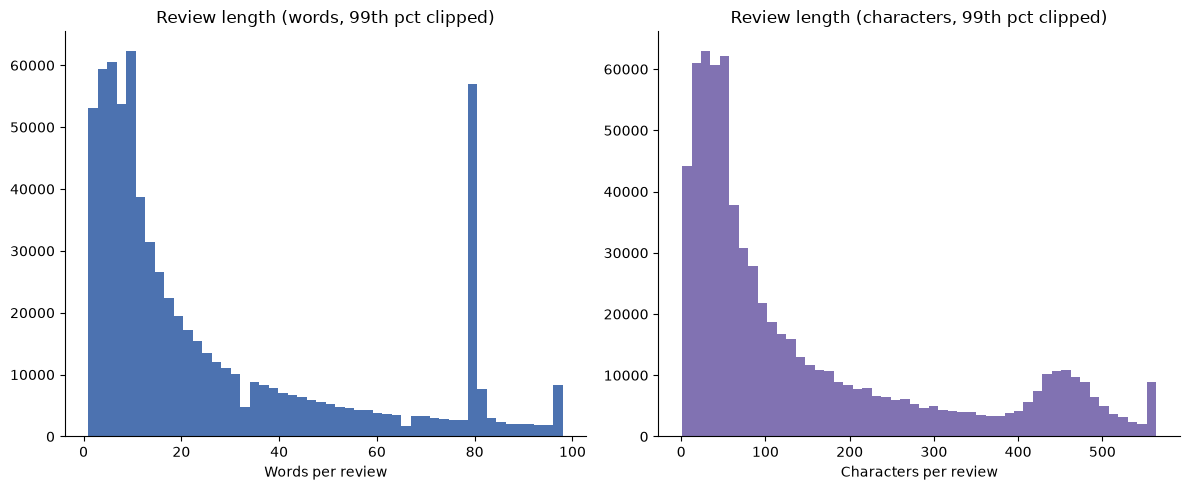

In [13]:
text = df["texto"].fillna("")
df["n_chars"] = text.str.len()
df["n_words"] = text.str.split().str.len()

display(df[["n_chars", "n_words"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["n_words"].clip(upper=df["n_words"].quantile(0.99)), bins=50, color="#4C72B0")
axes[0].set_title("Review length (words, 99th pct clipped)")
axes[0].set_xlabel("Words per review")
axes[1].hist(df["n_chars"].clip(upper=df["n_chars"].quantile(0.99)), bins=50, color="#8172B2")
axes[1].set_title("Review length (characters, 99th pct clipped)")
axes[1].set_xlabel("Characters per review")
plt.tight_layout()
plt.show()

## 10. Likes

count    710045.000000
mean          1.214705
std           7.427426
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        1704.000000
Name: likes, dtype: float64

Reviews with 0 likes: 69.4%


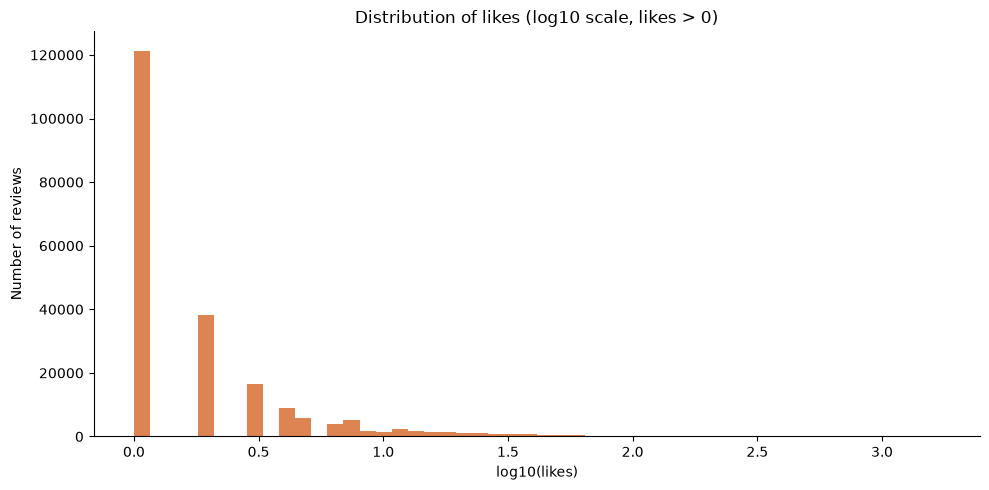

,pelicula_titulo,usuario,calificacion,likes,fecha
396164,Pan's Labyrinth,schaffrillas,4.5,1704,2026-09-10
73835,Biutiful,kurstboy,3.5,806,2026-06-24
460966,Simon of the Desert,kurstboy,4.0,622,2024-06-21
565094,The Intruder,nahuutwm,4.5,592,2021-10-05
132102,Cronos,schaffrillas,3.0,590,2026-08-27
427442,Radioactive Dreams,campbart,5.0,518,2020-03-19
626368,The Wolves,luisitouwu,4.0,493,2020-11-18
82647,Book of Love,rachelshanks,2.0,485,2022-02-05
473358,Strawberry and Chocolate,kelylucena,5.0,485,2015-05-02
134093,DIVE,sof,3.5,455,2022-10-29


In [14]:
display(df["likes"].describe())

zero_likes = (df["likes"] == 0).mean() * 100
print(f"Reviews with 0 likes: {zero_likes:.1f}%")

fig, ax = plt.subplots()
positive = df.loc[df["likes"] > 0, "likes"]
ax.hist(np.log10(positive), bins=50, color="#DD8452")
ax.set_title("Distribution of likes (log10 scale, likes > 0)")
ax.set_xlabel("log10(likes)")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

df.nlargest(10, "likes")[["pelicula_titulo", "usuario", "calificacion", "likes", "fecha"]]

## 12. Reviewed films by release year

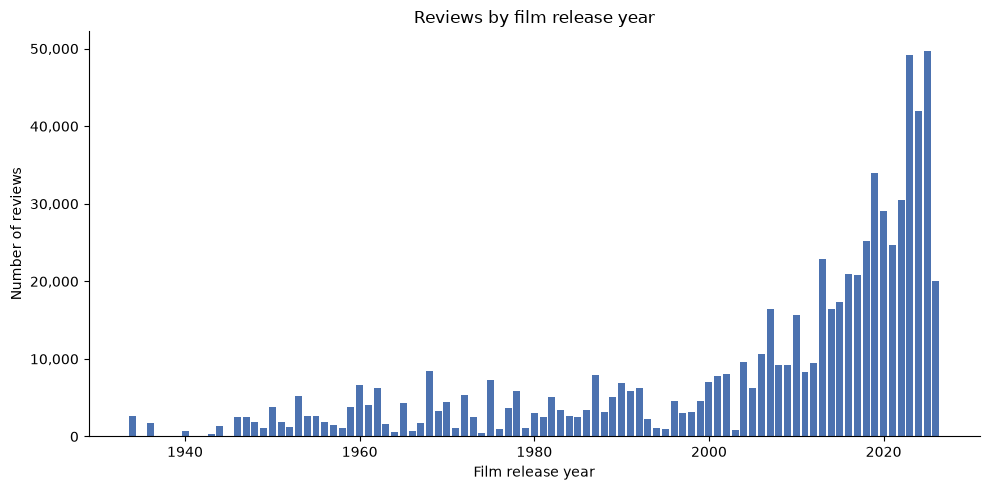

In [16]:
by_release_year = df[(df["pelicula_anio"] >= 1920) & (df["pelicula_anio"] <= 2026)]["pelicula_anio"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(by_release_year.index, by_release_year.values, color="#4C72B0", width=0.8)
ax.set_title("Reviews by film release year")
ax.set_xlabel("Film release year")
ax.set_ylabel("Number of reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 14. Summary of key findings

- **Size**: 710,045 reviews across only **868 unique films** (avg. ~818 reviews/film) and 340,692 unique reviewers. This is not a broad Letterboxd crawl — it's a **deep scrape of a narrow set of films**, collected in a single snapshot on 2026‑09‑18.
- **Ratings**: mean 3.38 / median 3.50 (0.5–5 scale), skewed toward mid‑high stars. 5.19% of reviews have **no star rating** (`calificacion` is `NaN`, not `0` — Letterboxd's minimum is 0.5, so `== 0` never occurs; the notebook was corrected to check for `NaN` instead of a naive `0` check).
- **Data quality**: no duplicate ids, no blank review text, but `idioma` is missing for 17.6% of rows and a few `fecha` values are corrupted placeholder dates (year 1, 2, 10, 777...) from what's likely a diary-entry default — those fall outside pandas' representable date range and were coerced to `NaT`, then explicitly flagged rather than silently distorting the date-range/time-series stats.
- **Concentration**: reviewers are heavily long-tailed — median 1 review/user, mean 2.08, max 343 from a single user. A small set of "power users" accounts for a disproportionate share of the volume (see the top-20 chart).
- **Language**: predominantly Spanish (43.6%) and English (27.3%), with Portuguese a distant third (3.5%) and a long tail of others — consistent with a Spanish-language-focused collection (`resenas` = Spanish for "reviews").
- **Engagement**: `likes` is heavily right-skewed — 69.4% of reviews get zero likes, and the top reviews concentrate likes by orders of magnitude more than the median.
- **Relationships**: correlations between rating, likes, and review length are all weak (|r| < 0.12) — longer or more-liked reviews are not meaningfully more positive or negative.
- **Unused fields**: `spoiler` and `es_relectura` are constant at 0 across all 710K rows — these flags exist in the schema but were never populated during collection, so they carry no signal in this dataset.

**Suggested next steps**: text-level analysis (sentiment, topic modeling on `texto`), per-film aggregate rating vs. Letterboxd's own public average (as a scrape-quality check), and bot/spam-account detection among the most prolific `usuario` values.